<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-HUYTRUONG/AIO/blob/aio/M4-Foundation-DL/Optimization/M04W01/Linear%20Regression/Optimize_sphere_2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import logging
import sys
from typing import Callable, List, Optional, Tuple
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True  # <--- BẮT BUỘC TRÊN COLAB / JUPYTER
)

logger = logging.getLogger(__name__)

logger.info("Test logger thành công trên Colab!")
logger.debug("Test debug log!")

2026-10-03 06:14:01,504 - INFO - Test logger thành công trên Colab!


In [ ]:
class GradientDescent2DOptimizer:
    """Trình tối ưu hóa Gradient Descent 2 chiều (tối ưu hóa f(x, y)).

    Attributes:
        objective_func (Callable[[float, float], float]): Hàm mục tiêu f(x, y).
        gradient_func (Callable[[float, float], Tuple[float, float]]): Hàm tính
          gradient (df/dx, df/dy).
        learning_rate (float): Tốc độ học (alpha / eta).
        num_steps (int): Số bước lặp tối đa.
    """

    def __init__(
        self,
        objective_func: Callable[[float, float], float],
        gradient_func: Callable[[float, float], Tuple[float, float]],
        learning_rate: float = 0.01,
        num_steps: int = 10,
    ) -> None:
      if learning_rate <= 0:
        raise ValueError("Tốc độ học phải lớn hơn 0")
      if num_steps <= 0:
        raise ValueError("Số bước lặp phải lớn hơn 0")

      self.objective_func = objective_func
      self.gradient_func = gradient_func
      self.learning_rate = learning_rate
      self.num_steps = num_steps

      # Lưu lịch sử di chuyển
      self.x_history: List[float] = []
      self.y_history: List[float] = []
      self.loss_history: List[float] = []

    def optimize(
        self,
        initial_point: Tuple[float, float],
    ) -> Tuple[float, float, float]:
      """
      Thực hiện tối ưu hóa từ điểm khởi tạo (x0, y0).

      Args:
          initial_point (Tuple[float, float]): Tọa độ khởi tạo (x, y).

      Returns:
          Tuple[float, float, float]: Tọa độ tối ưu (x_opt, y_opt) và giá trị Loss tương ứng.
      """

      x, y = initial_point[0], initial_point[1]

      # Lưu điểm khởi tạo (step 0)
      self.x_history = [x]
      self.y_history = [y]
      self.loss_history = [self.objective_func(x, y)]

      logger.info(f"Khởi tạo điểm xuất phát: (x0 = {x:.4f}, y0 = {y:.4f}) | Loss = {self.loss_history[0]:.4f}")

      for step in range(self.num_steps):
        dx_dy = self.gradient_func(x, y)
        x = x - self.learning_rate * dx_dy[0]
        y = y - self.learning_rate * dx_dy[1]
        loss = self.objective_func(x, y)

        self.x_history.append(x)
        self.y_history.append(y)
        self.loss_history.append(loss)

        logger.info(f"Bước {step:03d} | (x, y) = ({x:.6f}, {y:.6f}) | Loss = {loss:.6f} |")

      logger.info(f"Hoàn thành! (x_opt, y_opt) = ({x:.6f}, {y:.6f}) | f(x_opt, y_opt) = {self.loss_history[-1]:.6f}")
      return x, y, self.loss_history[-1]

    def plot_optimization_contour(
        self,
        x_range: Tuple[float, float] = (-4.5, 4.5),
        y_range: Tuple[float, float] = (-4.5, 4.5),
        grid_step: float = 0.1,
    ) -> None:
        """Vẽ đồ thị Contour (đường mức) thể hiện vết di chuyển của (x, y) trên
        mặt phẳng 2D."""
        if not self.x_history:
            raise RuntimeError("Vui lòng chạy .optimize() trước khi vẽ đồ thị!")

        # Tạo lưới tọa độ Meshgrid
        x_vals = np.arange(x_range[0], x_range[1] + grid_step, grid_step)
        y_vals = np.arange(y_range[0], y_range[1] + grid_step, grid_step)
        X, Y = np.meshgrid(x_vals, y_vals)
        Z = self.objective_func(X, Y)

        fig, ax = plt.subplots(figsize=(9, 7))

        # 1. Vẽ đường mức Contour
        contour = ax.contourf(X, Y, Z, levels=30, cmap="jet", alpha=0.75)
        fig.colorbar(contour, ax=ax, label="f(x, y)")
        ax.contour(X, Y, Z, levels=30, colors="black", linewidths=0.3, alpha=0.5)

        # 2. Vẽ đường di chuyển Trajectory
        ax.plot(
            self.x_history,
            self.y_history,
            "white",
            linestyle="--",
            linewidth=1.5,
            label="Trajectory",
        )
        ax.plot(
            self.x_history,
            self.y_history,
            "ro",
            markersize=4,
            label="Gradient Steps",
        )

        # 3. Đánh dấu Start & Optimum
        ax.scatter(
            self.x_history[0],
            self.y_history[0],
            color="lime",
            s=120,
            edgecolors="black",
            zorder=5,
            label=f"Start ({self.x_history[0]:.2f}, {self.y_history[0]:.2f})",
        )
        ax.scatter(
            self.x_history[-1],
            self.y_history[-1],
            color="gold",
            s=150,
            edgecolors="black",
            zorder=5,
            label=f"Optimum ({self.x_history[-1]:.2f}, {self.y_history[-1]:.2f})",
        )

        ax.set_title(
            f"Gradient Descent 2D Contour Trajectory (lr={self.learning_rate})",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_xlabel("x", fontsize=11)
        ax.set_ylabel("y", fontsize=11)
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

    def plot_optimization_3d(
        self,
        x_range: Tuple[float, float] = (-4.5, 4.5),
        y_range: Tuple[float, float] = (-4.5, 4.5),
        grid_step: float = 0.2,
    ) -> None:
        """Vẽ đồ thị không gian 3D biểu diễn mặt cong f(x, y) và đường đi xuống
        đáy."""
        if not self.x_history:
            raise RuntimeError("Vui lòng chạy .optimize() trước khi vẽ đồ thị!")

        x_vals = np.arange(x_range[0], x_range[1] + grid_step, grid_step)
        y_vals = np.arange(y_range[0], y_range[1] + grid_step, grid_step)
        X, Y = np.meshgrid(x_vals, y_vals)
        Z = self.objective_func(X, Y)

        fig = plt.figure(figsize=(10, 7))
        ax = plt.axes(projection="3d", elev=35, azim=-55)

        # Vẽ mặt cong 3D
        ax.plot_surface(
            X,
            Y,
            Z,
            rstride=1,
            cstride=1,
            edgecolor="none",
            alpha=0.6,
            cmap="jet",
            norm=LogNorm() if np.min(Z) > 0 else None,
        )

        # Vẽ quỹ đạo 3D
        ax.plot(
            self.x_history,
            self.y_history,
            self.loss_history,
            color="red",
            linewidth=2,
            marker="o",
            markersize=4,
            label="Optimization Path",
        )

        # Đánh dấu Start & Optimum 3D
        ax.scatter(
            self.x_history[0],
            self.y_history[0],
            self.loss_history[0],
            color="lime",
            s=100,
            edgecolors="black",
            label="Start",
        )
        ax.scatter(
            self.x_history[-1],
            self.y_history[-1],
            self.loss_history[-1],
            color="gold",
            s=120,
            edgecolors="black",
            label="Optimum",
        )

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("f(x, y)")
        ax.set_title("3D Loss Surface and Optimization Path", fontweight="bold")
        ax.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
# Hàm mục tiêu: f(x, y) = x^2 + y^2
def target_function_2d(x: float, y: float) -> float:
    return x**2 + y**2

# Vector Gradient (Đạo hạm riêng): df/dx = 2x, df/dy = 2y
def target_gradient_2d(x: float, y: float) -> Tuple[float, float]:
  dx = 2*x
  dy = 2*y
  return dx,dy

# Sử dụng generator sinh số ngẫu nhiên ngầm định theo seed
rng = np.random.default_rng(seed=42)
# start_point = (x0, y0)
start_point = (
    float(rng.uniform(-4.0, 4.0)),
    float(rng.uniform(-4.0, 4.0))
)
x, y = start_point[0], start_point[1]
# print(f"Tọa độ khởi tạo: f(x0, y0) ({x}, {y})")

num_steps = 10
lr = 0.1

optimizer = GradientDescent2DOptimizer(
    objective_func=target_function_2d,
    gradient_func=target_gradient_2d,
    learning_rate=lr,
    num_steps=num_steps
)
# Thực thi quá trình tìm điểm tối ưu
x_opt, y_opt, min_loss = optimizer.optimize(initial_point=start_point)

2026-10-03 06:14:01,597 - INFO - Khởi tạo điểm xuất phát: (x0 = 2.1916, y0 = -0.4890) | Loss = 5.0424
2026-10-03 06:14:01,599 - INFO - Bước 000 | (x, y) = (1.753319, -0.391178) | Loss = 3.227147 |
2026-10-03 06:14:01,600 - INFO - Bước 001 | (x, y) = (1.402655, -0.312942) | Loss = 2.065374 |
2026-10-03 06:14:01,600 - INFO - Bước 002 | (x, y) = (1.122124, -0.250354) | Loss = 1.321839 |
2026-10-03 06:14:01,601 - INFO - Bước 003 | (x, y) = (0.897699, -0.200283) | Loss = 0.845977 |
2026-10-03 06:14:01,602 - INFO - Bước 004 | (x, y) = (0.718159, -0.160227) | Loss = 0.541425 |
2026-10-03 06:14:01,603 - INFO - Bước 005 | (x, y) = (0.574527, -0.128181) | Loss = 0.346512 |
2026-10-03 06:14:01,604 - INFO - Bước 006 | (x, y) = (0.459622, -0.102545) | Loss = 0.221768 |
2026-10-03 06:14:01,605 - INFO - Bước 007 | (x, y) = (0.367698, -0.082036) | Loss = 0.141931 |
2026-10-03 06:14:01,605 - INFO - Bước 008 | (x, y) = (0.294158, -0.065629) | Loss = 0.090836 |
2026-10-03 06:14:01,606 - INFO - Bước 009 |

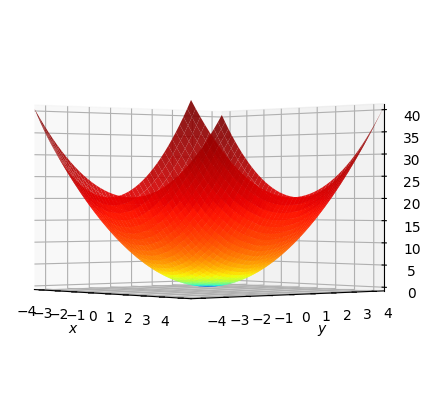

In [ ]:
xmin, xmax, xstep = -4.5, 4.5, .2
ymin, ymax, ystep = -4.5, 4.5, .2

x, y = np.meshgrid(np.arange(xmin, xmax + xstep, xstep), np.arange(ymin, ymax + ystep, ystep))
z = target_function_2d(x, y)

# 3D Surface Plot
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection='3d', elev=0, azim=-40)

ax.plot_surface(x, y, z, norm=LogNorm(), rstride=1, cstride=1,
                edgecolor='none', alpha=.9, cmap=plt.cm.jet)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))

plt.show()

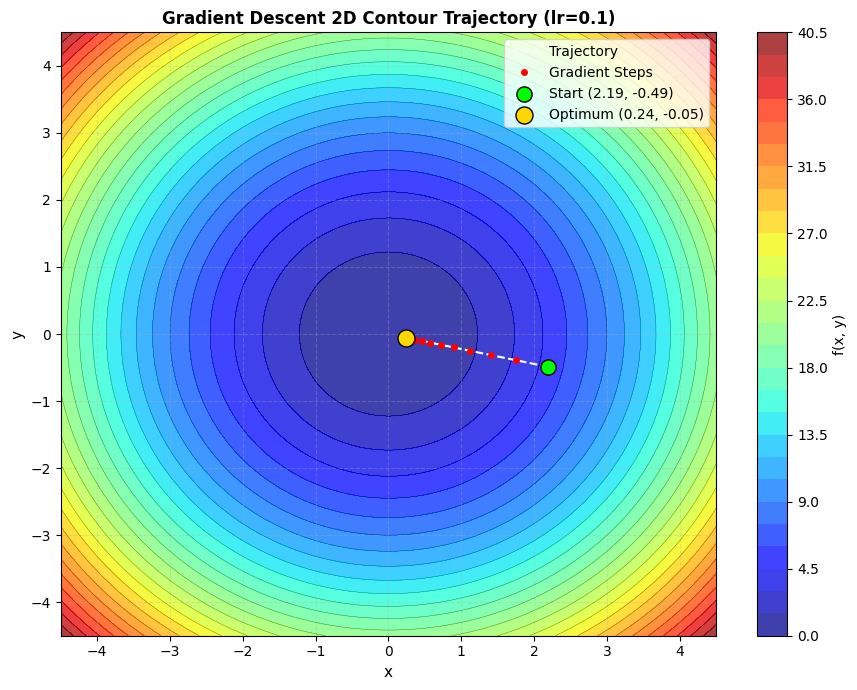

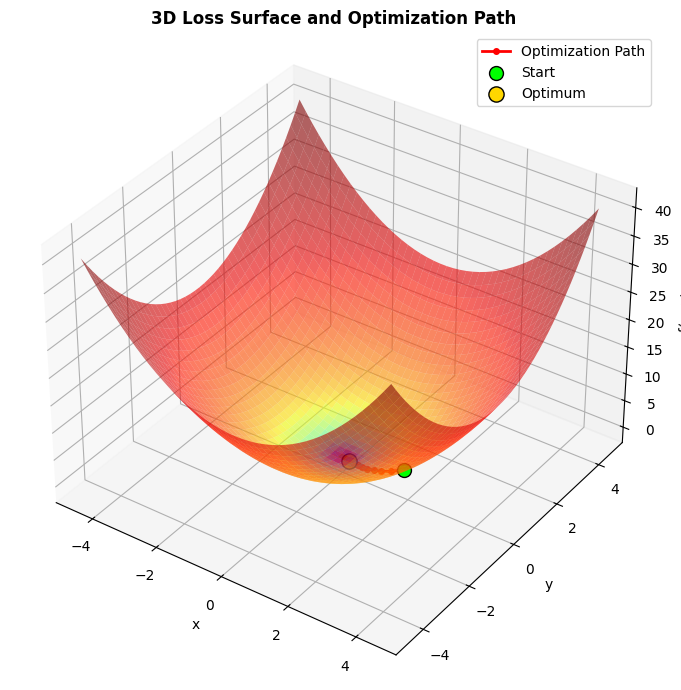

In [ ]:
# Trực quan hóa
optimizer.plot_optimization_contour(x_range=(-4.5, 4.5), y_range=(-4.5, 4.5))
optimizer.plot_optimization_3d(x_range=(-4.5, 4.5), y_range=(-4.5, 4.5))